<a href="https://colab.research.google.com/github/Moulini/ml-leakage-pipeline-moulini/blob/main/Regression_predicting_values.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler



# Create dataset (60 records)
n = 60
area_sqft = np.random.randint(600, 3000, n)
num_bedrooms = np.random.randint(1, 6, n)
age_years = np.random.randint(0, 30, n)
price_lakhs = (
    area_sqft * 0.06 +
    num_bedrooms * 8 -
    age_years * 0.4 +
    np.random.normal(0, 5, n)
)

# DataFrame
df = pd.DataFrame({
    "area_sqft": area_sqft,
    "num_bedrooms": num_bedrooms,
    "age_years": age_years,
    "price_lakhs": price_lakhs
})

# Features & target
X = df[["area_sqft", "num_bedrooms", "age_years"]]
y = df["price_lakhs"]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42
)

model = LinearRegression()
model.fit(X, y)

print("Coefficients:")

for feature, coef in zip(X.columns, model.coef_):

    print(f"  {feature:12s}: {coef:+.3f}")

print(f"  {'intercept':12s}: {model.intercept_:+.3f}")

y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print("\nFirst 5 Actual vs Predicted:\n")
print(comparison.head())

Coefficients:
  area_sqft   : +0.060
  num_bedrooms: +7.349
  age_years   : -0.266
  intercept   : +0.135

First 5 Actual vs Predicted:

       Actual  Predicted
0  163.989387 -10.665757
1  208.002275  10.647232
2  171.369517  10.353538
3   39.076402 -10.565365
4  149.634706 -11.031632


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2   = r2_score(y_test, y_pred)

print(f"MAE  (Mean Absolute Error)  : {mae:.2f}  lakhs")

print(f"RMSE (Root Mean Sq Error)   : {rmse:.2f} lakhs")

print(f"R²   (R-squared)            : {r2:.3f}")



MAE  (Mean Absolute Error)  : 141.96  lakhs
RMSE (Root Mean Sq Error)   : 149.59 lakhs
R²   (R-squared)            : -8.304


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


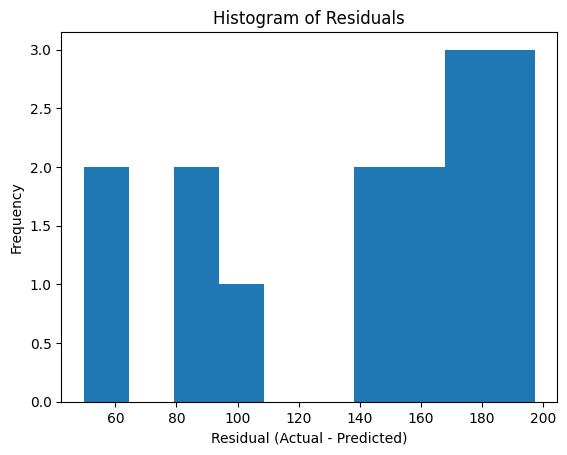

In [16]:
import matplotlib.pyplot as plt

residuals = y_test - y_pred

# Plot histogram
plt.figure()
plt.hist(residuals)
plt.title("Histogram of Residuals")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.show()